# DINOv3 frozen-feature testing on a custom dataset (no training)

This notebook uses DINOv3 as a **frozen feature extractor** on your own images:

1. Extract a global embedding (CLS / `pooler_output`) for every image
2. If images are in class subfolders: **k-NN accuracy** (cross-validated) and **nearest-neighbour retrieval accuracy**
3. Visual check of nearest neighbours
4. PCA visualization of **patch features** (dense feature sanity check)

**Dataset layout** (labels optional):
```
data/
  class_a/img1.jpg ...
  class_b/img7.jpg ...
```
or simply a flat folder of images.

**Before running:** open the model page on Hugging Face (e.g. `facebook/dinov3-vits16-pretrain-lvd1689m`) and accept the license — the weights are gated.

## 1. Setup

In [1]:
%pip install -q "transformers>=4.56" torch pillow scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Log in with a Hugging Face token from the account that accepted the DINOv3 license
from huggingface_hub import notebook_login
notebook_login()

## 2. Configuration
Edit these to match your data and hardware.

In [3]:
DATA_DIR   = "./data"                                    # folder with your images
MODEL_NAME = "facebook/dinov3-vits16-pretrain-lvd1689m"  # try vitb16 / vitl16 for stronger features
BATCH_SIZE = 32
K          = 20                                          # neighbours for k-NN
OUT_DIR    = "./dinov3_out"

## 3. Imports and device

In [4]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Device:", device)

out_dir = Path(OUT_DIR)
out_dir.mkdir(exist_ok=True)

c:\Users\Ehsani\Github repos\DinoSurge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 4. Load the model

In [5]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
print(f"Loaded {MODEL_NAME}")

c:\Users\Ehsani\Github repos\DinoSurge\.venv\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ehsani\.cache\huggingface\hub\models--facebook--dinov3-vits16-pretrain-lvd1689m. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\Ehsani\Github repos\DinoSurge\.venv\Lib\site-packages\huggingface_hub\fil

Loaded facebook/dinov3-vits16-pretrain-lvd1689m


## 5. Find images (and labels from subfolder names)

In [6]:
EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

root = Path(DATA_DIR)
paths = sorted(p for p in root.rglob("*") if p.suffix.lower() in EXTS)
if not paths:
    raise FileNotFoundError(f"No images found in {DATA_DIR}")

raw_labels = [p.parent.name if p.parent != root else None for p in paths]
has_labels = all(l is not None for l in raw_labels) and len(set(raw_labels)) > 1
labels = np.array(raw_labels) if has_labels else None

print(f"Found {len(paths)} images")
if has_labels:
    classes, counts = np.unique(labels, return_counts=True)
    for c, n in zip(classes, counts):
        print(f"  {c}: {n}")
else:
    print("No class subfolders detected — running unlabeled analysis only.")

Found 50 images
No class subfolders detected — running unlabeled analysis only.


## 6. Extract embeddings

In [7]:
@torch.inference_mode()
def extract_features(paths, batch_size=BATCH_SIZE):
    feats = []
    for i in tqdm(range(0, len(paths), batch_size), desc="Extracting"):
        imgs = [Image.open(p).convert("RGB") for p in paths[i:i + batch_size]]
        inputs = processor(images=imgs, return_tensors="pt").to(device)
        out = model(**inputs)
        feats.append(out.pooler_output.float().cpu())
    feats = torch.cat(feats)
    return torch.nn.functional.normalize(feats, dim=1).numpy()  # L2-normalize

feats = extract_features(paths)
print("Embeddings shape:", feats.shape)

np.save(out_dir / "features.npy", feats)
(out_dir / "paths.txt").write_text("\n".join(str(p) for p in paths))
print("Saved to", out_dir)

Extracting: 100%|██████████| 2/2 [00:03<00:00,  1.67s/it]

Embeddings shape: (50, 384)
Saved to dinov3_out


## 7. k-NN classification (needs class subfolders)
Training-free benchmark: each image's label is predicted from its most similar images, with cross-validation.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

if has_labels:
    min_count = np.unique(labels, return_counts=True)[1].min()
    n_splits = min(5, int(min_count))
    if n_splits < 2:
        print("Skipped: every class needs at least 2 images.")
    else:
        clf = KNeighborsClassifier(n_neighbors=min(K, len(labels) - 1),
                                   metric="cosine", weights="distance")
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
        scores = cross_val_score(clf, feats, labels, cv=cv)
        print(f"k-NN accuracy ({n_splits}-fold CV, k={clf.n_neighbors}): "
              f"{scores.mean():.3f} ± {scores.std():.3f}")
else:
    print("Skipped: no labels.")

Skipped: no labels.


## 8. Nearest-neighbour retrieval

In [9]:
sims = feats @ feats.T              # cosine similarity (features are normalized)
np.fill_diagonal(sims, -np.inf)     # exclude self-matches
nn = sims.argmax(axis=1)

if has_labels:
    print(f"Top-1 retrieval accuracy: {(labels[nn] == labels).mean():.3f}")

for i in range(min(5, len(paths))):
    print(f"{paths[i].name}  ->  {paths[nn[i]].name}  (cos sim {sims[i, nn[i]]:.3f})")

camera01_colorimage-000000.jpg  ->  camera01_colorimage-000098.jpg  (cos sim 0.938)
camera01_colorimage-000014.jpg  ->  camera01_colorimage-000042.jpg  (cos sim 0.934)
camera01_colorimage-000028.jpg  ->  camera01_colorimage-000224.jpg  (cos sim 0.923)
camera01_colorimage-000042.jpg  ->  camera01_colorimage-000014.jpg  (cos sim 0.934)
camera01_colorimage-000056.jpg  ->  camera01_colorimage-000098.jpg  (cos sim 0.942)


### Visual check: a query image and its top-5 most similar images

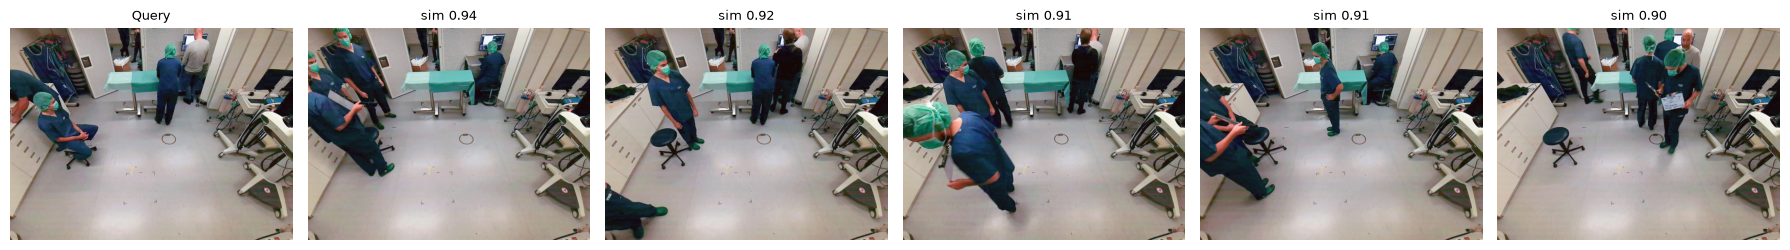

In [10]:
QUERY_IDX = 0   # change to inspect other images
TOP = 5

order = np.argsort(-sims[QUERY_IDX])[:TOP]
fig, axes = plt.subplots(1, TOP + 1, figsize=(3 * (TOP + 1), 3.4))
axes[0].imshow(Image.open(paths[QUERY_IDX]).convert("RGB"))
axes[0].set_title("Query" + (f"\n{labels[QUERY_IDX]}" if has_labels else ""), fontsize=9)
for ax, j in zip(axes[1:], order):
    ax.imshow(Image.open(paths[j]).convert("RGB"))
    title = f"sim {sims[QUERY_IDX, j]:.2f}" + (f"\n{labels[j]}" if has_labels else "")
    ax.set_title(title, fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Patch-feature PCA visualization (ViT models only)
Projects each patch's feature vector to RGB. If DINOv3 understands your domain, objects and parts show up as coherent colored regions.

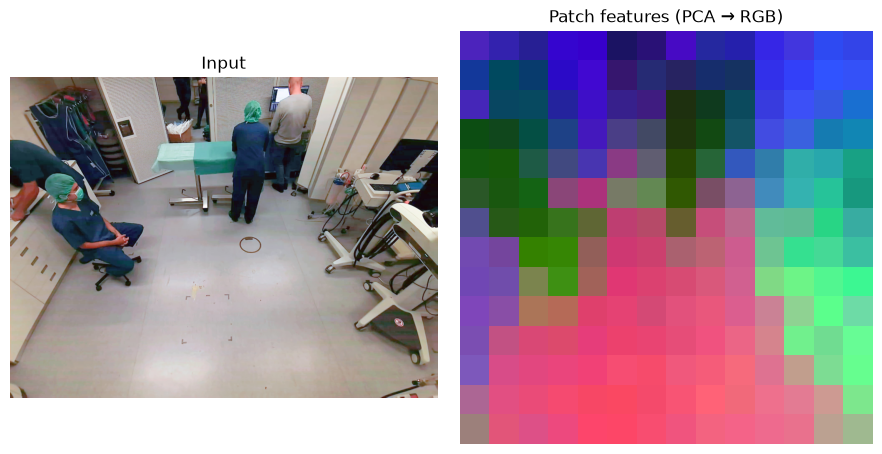

In [11]:
from sklearn.decomposition import PCA

@torch.inference_mode()
def show_patch_pca(path):
    if not hasattr(model.config, "patch_size"):
        print("Skipped: only for ViT variants, not ConvNeXt.")
        return
    img = Image.open(path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    h, w = inputs["pixel_values"].shape[-2:]
    out = model(**inputs)
    n_skip = 1 + getattr(model.config, "num_register_tokens", 0)   # CLS + register tokens
    patches = out.last_hidden_state[0, n_skip:].float().cpu().numpy()
    ps = model.config.patch_size

    rgb = PCA(n_components=3).fit_transform(patches)
    rgb = (rgb - rgb.min(0)) / (rgb.max(0) - rgb.min(0) + 1e-8)
    rgb = rgb.reshape(h // ps, w // ps, 3)

    fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
    ax[0].imshow(img); ax[0].set_title("Input"); ax[0].axis("off")
    ax[1].imshow(rgb); ax[1].set_title("Patch features (PCA → RGB)"); ax[1].axis("off")
    plt.tight_layout()
    plt.show()

show_patch_pca(paths[0])

## 10. Optional: 2-D embedding map
A quick look at how your dataset clusters in DINOv3 feature space.

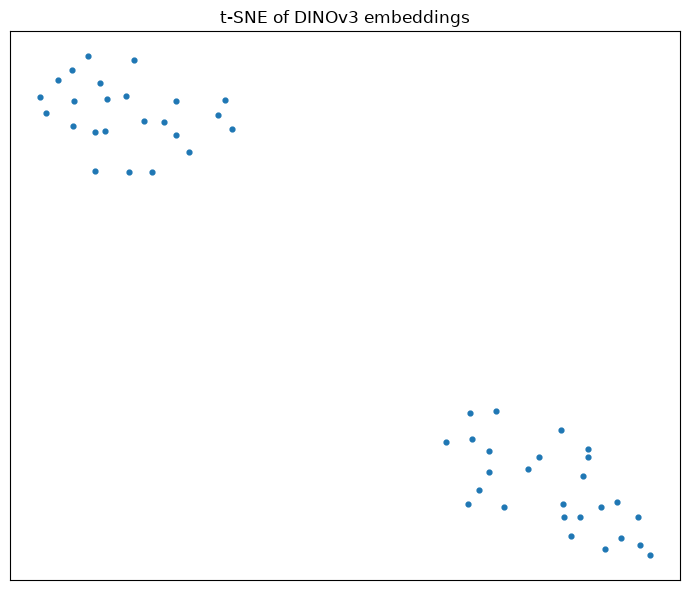

In [12]:
from sklearn.manifold import TSNE

perplexity = min(30, max(2, len(feats) // 4))
emb2d = TSNE(n_components=2, perplexity=perplexity, init="pca", random_state=0).fit_transform(feats)

plt.figure(figsize=(7, 6))
if has_labels:
    for c in np.unique(labels):
        m = labels == c
        plt.scatter(emb2d[m, 0], emb2d[m, 1], s=12, label=c)
    plt.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
else:
    plt.scatter(emb2d[:, 0], emb2d[:, 1], s=12)
plt.title("t-SNE of DINOv3 embeddings")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()


## 11. Outline regions in every image (unsupervised segmentation, no training)
DINOv3's patch features are grouped with k-means, and the region boundaries are drawn on each image.
The regions have **no names** — they are parts of the image that DINOv3 considers similar (objects, object parts, background areas).

Results are saved to `dinov3_out/segments/`.

- `SEG_MODE = "dataset"`: clusters are shared across all images, so **the same color means the same kind of region** in every image
- `SEG_MODE = "per_image"`: each image is segmented on its own (colors are not comparable between images)
- Increase `N_SEGMENTS` for finer splits (object parts), decrease for coarser ones (object vs background)
- Increase `SEG_RES` for sharper outlines (slower, more memory)


In [13]:
SEG_RES    = 448         # longer image side fed to DINOv3 (multiple of 16 is used)
N_SEGMENTS = 5           # number of region types
SEG_MODE   = "dataset"   # "dataset" or "per_image"
OUT_MAX    = 1024        # longer side of the saved overlay images
ALPHA      = 0.35        # fill transparency (0 = outlines only)
OUTLINE    = (255, 255, 0)
 
from sklearn.cluster import KMeans, MiniBatchKMeans
import torch.nn.functional as F
 
assert hasattr(model.config, "patch_size"), "Segmentation needs a ViT model, not ConvNeXt."
seg_dir = out_dir / "segments"
seg_dir.mkdir(exist_ok=True)
 
ps     = model.config.patch_size
n_skip = 1 + getattr(model.config, "num_register_tokens", 0)   # CLS + register tokens
mean   = torch.tensor(processor.image_mean).view(3, 1, 1)
std    = torch.tensor(processor.image_std).view(3, 1, 1)
palette = (plt.get_cmap("tab10" if N_SEGMENTS <= 10 else "tab20")(np.arange(N_SEGMENTS))[:, :3] * 255).astype(np.uint8)
 
def preprocess(img):
    """Resize keeping aspect ratio so both sides are multiples of the patch size."""
    w, h = img.size
    s = SEG_RES / max(w, h)
    nw, nh = max(ps, round(w * s / ps) * ps), max(ps, round(h * s / ps) * ps)
    x = np.asarray(img.resize((nw, nh), Image.BICUBIC), dtype=np.float32) / 255.0
    x = torch.from_numpy(x).permute(2, 0, 1)
    return ((x - mean) / std).unsqueeze(0), nh // ps, nw // ps
 
@torch.inference_mode()
def patch_features(img):
    x, gh, gw = preprocess(img)
    out = model(pixel_values=x.to(device))
    f = out.last_hidden_state[0, n_skip:].float().cpu()
    assert f.shape[0] == gh * gw, f"Unexpected token count {f.shape[0]} vs grid {gh}x{gw}"
    return F.normalize(f, dim=1).numpy(), gh, gw
 
def label_map(f, gh, gw, centers, H, W):
    """Soft-assign patches to clusters, upsample smoothly, then pick the best cluster per pixel."""
    sim = (f @ centers.T).T.reshape(1, -1, gh, gw)
    sim = F.interpolate(torch.from_numpy(sim), size=(H, W), mode="bilinear", align_corners=False)
    return sim[0].argmax(0).numpy()
 
def boundaries(lab, thickness=2):
    b = np.zeros(lab.shape, bool)
    b[:-1] |= lab[:-1] != lab[1:]
    b[:, :-1] |= lab[:, :-1] != lab[:, 1:]
    for _ in range(thickness - 1):
        t = b.copy()
        t[1:] |= b[:-1]; t[:-1] |= b[1:]; t[:, 1:] |= b[:, :-1]; t[:, :-1] |= b[:, 1:]
        b = t
    return b
 
def draw(img, lab):
    arr = np.asarray(img, dtype=np.float32)
    out = arr * (1 - ALPHA) + palette[lab].astype(np.float32) * ALPHA
    out[boundaries(lab)] = OUTLINE
    return Image.fromarray(out.clip(0, 255).astype(np.uint8))
 
# Pass 1: patch features for every image
patch_data = []
for p in tqdm(paths, desc="Patch features"):
    patch_data.append(patch_features(Image.open(p).convert("RGB")))
 
# Shared clusters across the dataset (same color = same region type everywhere)
if SEG_MODE == "dataset":
    all_f = np.concatenate([f for f, _, _ in patch_data])
    rng = np.random.default_rng(0)
    if len(all_f) > 200_000:
        all_f = all_f[rng.choice(len(all_f), 200_000, replace=False)]
    km = MiniBatchKMeans(n_clusters=N_SEGMENTS, random_state=0, n_init=3, batch_size=4096).fit(all_f)
    shared_centers = km.cluster_centers_ / np.linalg.norm(km.cluster_centers_, axis=1, keepdims=True)
 
# Pass 2: segment, outline, save
overlays = []
for p, (f, gh, gw) in tqdm(list(zip(paths, patch_data)), desc="Drawing outlines"):
    if SEG_MODE == "dataset":
        centers = shared_centers
    else:
        k = min(N_SEGMENTS, len(f))
        c = KMeans(n_clusters=k, random_state=0, n_init=5).fit(f).cluster_centers_
        centers = c / np.linalg.norm(c, axis=1, keepdims=True)
    img = Image.open(p).convert("RGB")
    s = min(1.0, OUT_MAX / max(img.size))
    img = img.resize((round(img.width * s), round(img.height * s)), Image.BICUBIC)
    lab = label_map(f, gh, gw, centers, img.height, img.width)
    ov = draw(img, lab)
    rel = p.relative_to(root).with_suffix("")
    save_path = seg_dir / (str(rel).replace("/", "__").replace("\\", "__") + "_segments.png")
    ov.save(save_path)
    overlays.append((p, img, ov))
 
print(f"Saved {len(overlays)} outlined images to {seg_dir}")

Drawing outlines: 100%|██████████| 50/50 [00:16<00:00,  3.10it/s]

Saved 50 outlined images to dinov3_out\segments


## Preview: original vs. outlined regions

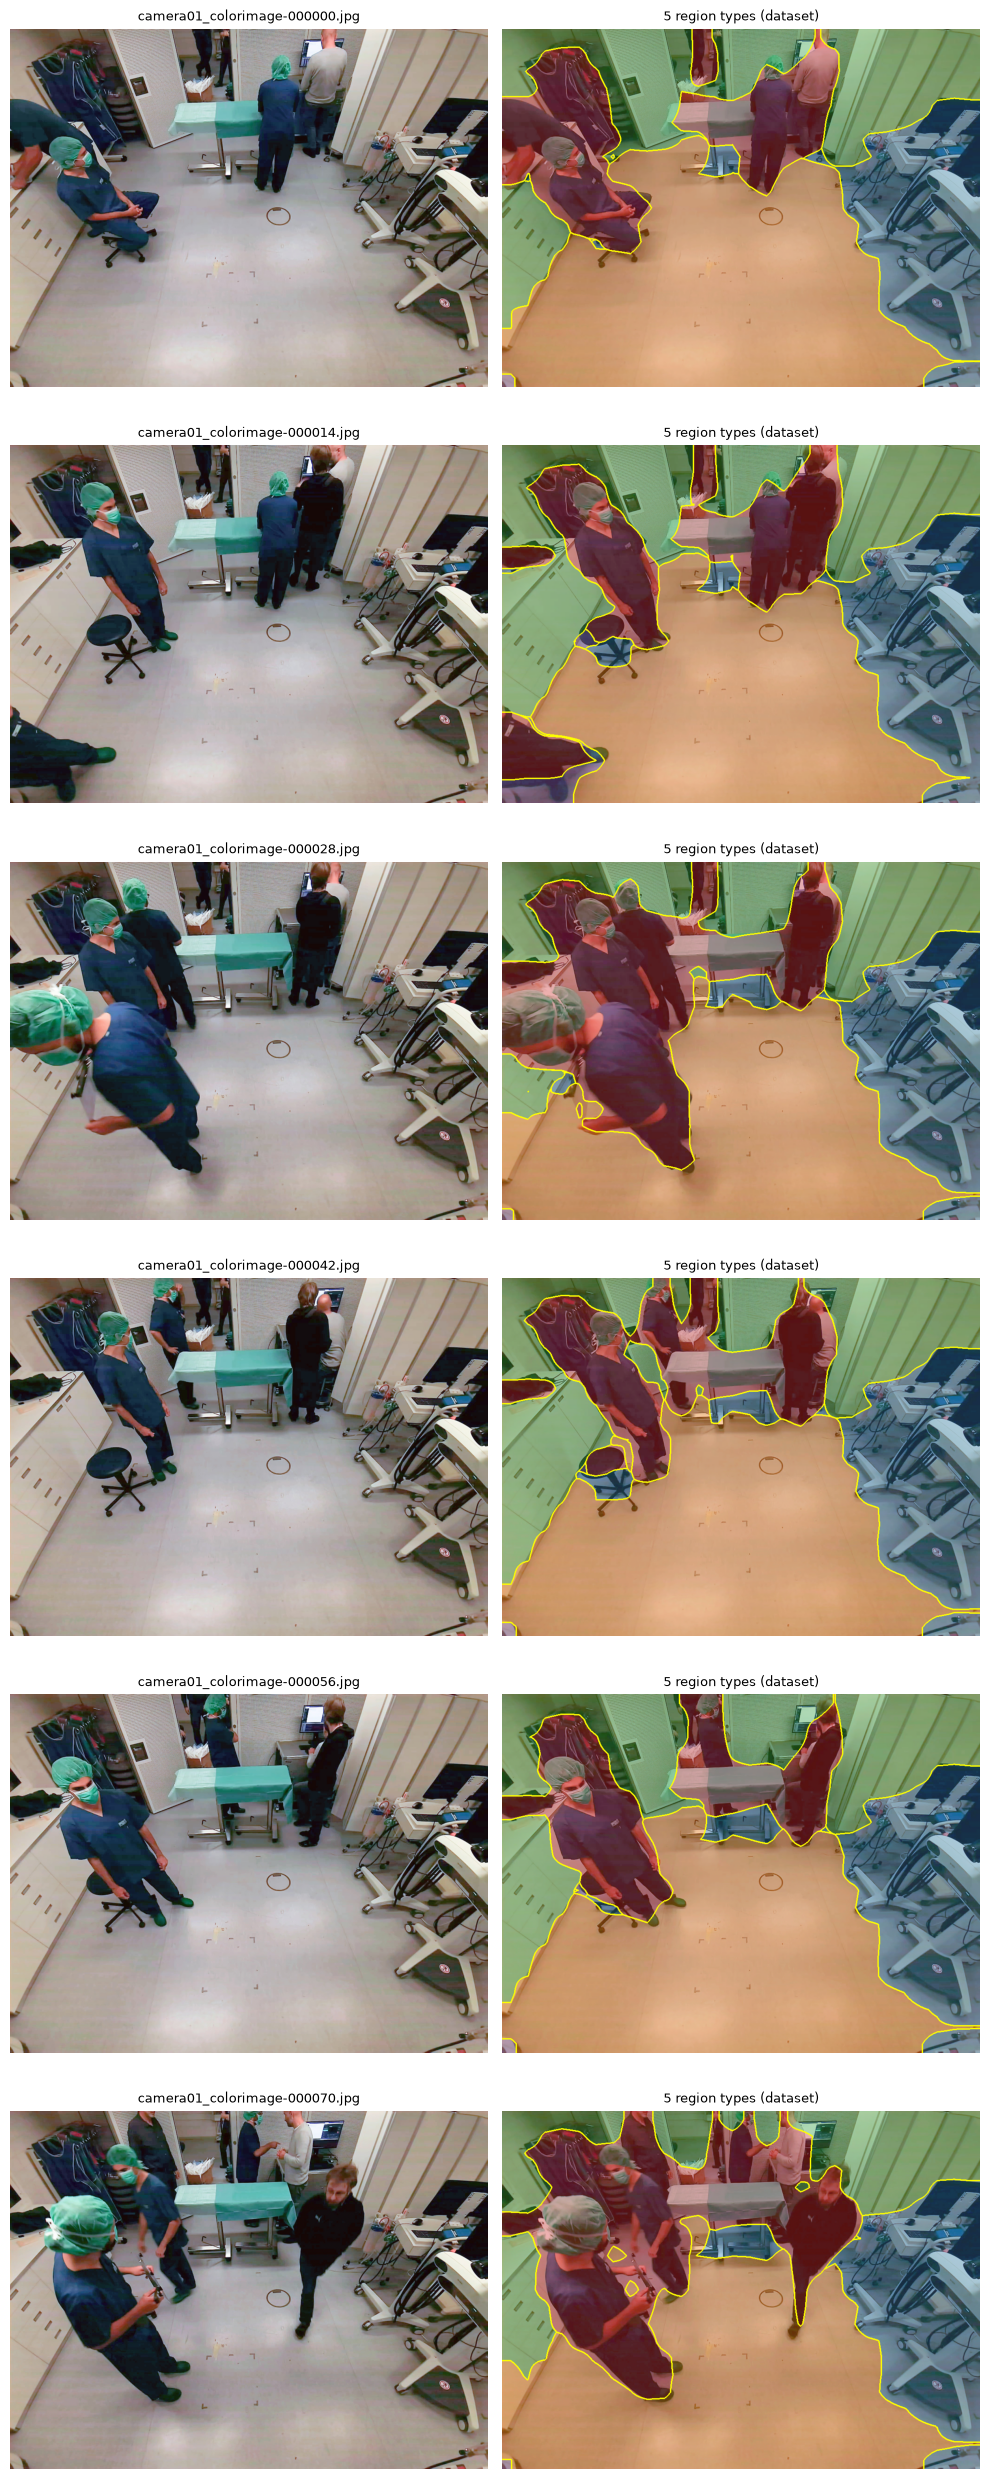

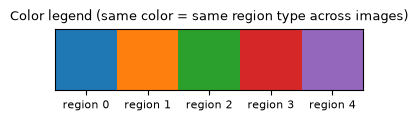

In [14]:
MAX_SHOW = 6
 
show = overlays[:MAX_SHOW]
fig, axes = plt.subplots(len(show), 2, figsize=(10, 4.2 * len(show)), squeeze=False)
for row, (p, img, ov) in zip(axes, show):
    row[0].imshow(img); row[0].set_title(p.name, fontsize=9)
    row[1].imshow(ov);  row[1].set_title(f"{N_SEGMENTS} region types ({SEG_MODE})", fontsize=9)
    for ax in row:
        ax.axis("off")
plt.tight_layout()
plt.show()
 
if SEG_MODE == "dataset":
    fig, ax = plt.subplots(figsize=(N_SEGMENTS * 1.1, 0.8))
    ax.imshow(palette[None, :, :]); ax.set_yticks([])
    ax.set_xticks(range(N_SEGMENTS)); ax.set_xticklabels([f"region {i}" for i in range(N_SEGMENTS)], fontsize=8)
    ax.set_title("Color legend (same color = same region type across images)", fontsize=9)
    plt.show()